# Medical Appointment No-Show Prediction

**Dataset**: KaggleV2-May-2016.csv (~110,527 rows)

**Target**: `target = 1` → patient did **not show** up

### Version history

- **v3.3** (previous major iteration)  
  - Random 80/20 split (`train_test_split` with `stratify=y`)  
  - Very strong risk of **future leakage** — many patients have multiple appointments; later appointments were used to predict earlier ones  
  - Over-optimistic CV / test scores (commonly 0.02–0.04 too high on ROC AUC)

- **v4.0** (current before this change)  
  - Switched to native categorical support in XGBoost  
  - Grouped rare neighborhoods → 'Other'  
  - Added patient history features (cumulative no-shows, prev rate, days since last)  
  - Still using **random stratified split** → leakage still present

- **v4.1** (this update – time-aware split)  
  - Replaced random split with **chronological split** on `scheduled_day`  
  - 80% earliest scheduled appointments → train, 20% most recent → test  
  - Much more realistic simulation of real-world usage (predicting future from past)  
  - Expected: train AUC drops a bit, test AUC may stay similar or slightly improve → more trustworthy generalization

In [45]:
# This code is part of a machine learning pipeline that uses XGBoost for classification tasks. It includes data preprocessing, model training, and evaluation steps. The necessary libraries are imported, and the XGBoost version is printed for reference.
# The code is structured to handle data manipulation with pandas, visualization with seaborn and matplotlib, and machine learning tasks with scikit-learn and XGBoost.  
# Note: The actual data loading, preprocessing, model training, and evaluation steps are not included in this snippet and would need to be implemented separately.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split    
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report 
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import xgboost as xgb

pd.set_option('display.max_columns', 50) 
sns.set(style="whitegrid")               
%matplotlib inline                       
# %matplotlib inline is a magic command in Jupyter notebooks that allows for the display of matplotlib plots directly within the notebook.  


print("XGBoost version:", xgb.__version__) # XGBoost library version. 

XGBoost version: 3.2.0


## 1. Load data

In [46]:
df = pd.read_csv('KaggleV2-May-2016.csv', parse_dates=['ScheduledDay', 'AppointmentDay'])

print('Shape:', df.shape)
print('\nNo-show rate:')
print(df['No-show'].value_counts(normalize=True).round(4))

Shape: (110527, 14)

No-show rate:
No-show
No     0.7981
Yes    0.2019
Name: proportion, dtype: float64


## 2. Cleaning & feature engineering

In [47]:
df = df.rename(columns={
    'PatientId': 'patient_id', 'AppointmentID': 'appointment_id',
    'Gender': 'gender', 'ScheduledDay': 'scheduled_day',
    'AppointmentDay': 'appointment_day', 'Age': 'age',
    'Neighbourhood': 'neighborhood', 'Scholarship': 'scholarship',
    'Hipertension': 'hypertension', 'Diabetes': 'diabetes',
    'Alcoholism': 'alcoholism', 'Handcap': 'handicap',
    'SMS_received': 'sms_received', 'No-show': 'no_show'
})

df['target'] = df['no_show'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['no_show'])

df['wait_days'] = (df['appointment_day'].dt.normalize() - df['scheduled_day'].dt.normalize()).dt.days.clip(lower=0)
df['scheduled_hour'] = df['scheduled_day'].dt.hour
df['appointment_dow'] = df['appointment_day'].dt.day_name()
df['appointment_is_weekend'] = df['appointment_day'].dt.weekday >= 5
df['same_day'] = (df['wait_days'] == 0).astype(int)

df = df[(df['age'] >= 0) & (df['age'] <= 115)]
df['handicap_binary'] = (df['handicap'] > 0).astype(int)

# Patient history features
df = df.sort_values(['patient_id', 'scheduled_day'])
df['prev_appointments'] = df.groupby('patient_id').cumcount()
df['cum_no_shows'] = df.groupby('patient_id')['target'].cumsum().shift(1).fillna(0)
df['prev_no_show_rate'] = np.where(df['prev_appointments'] > 0, df['cum_no_shows'] / df['prev_appointments'], 0.0)
df['days_since_last'] = df.groupby('patient_id')['appointment_day'].diff().dt.days.fillna(999)

print('Cleaned shape:', df.shape)

Cleaned shape: (110526, 24)


In [48]:
# ────────────────────────────────────────────────────────────────
# Define feature lists once – used for both old and new split styles
# ────────────────────────────────────────────────────────────────

numeric_features = [
    'age', 'wait_days', 'scheduled_hour', 'scholarship', 'hypertension',
    'diabetes', 'alcoholism', 'handicap_binary', 'sms_received',
    'prev_no_show_rate', 'days_since_last', 'same_day', 'appointment_is_weekend'
]

cat_features = ['gender', 'appointment_dow', 'neighborhood']

print("Numeric features:", len(numeric_features))
print("Categorical features:", cat_features)

Numeric features: 13
Categorical features: ['gender', 'appointment_dow', 'neighborhood']


## 3. Group rare neighborhoods (prevents unseen category error)

In [49]:
rare_threshold = 50
neigh_counts = df['neighborhood'].value_counts()
rare_neigh = neigh_counts[neigh_counts < rare_threshold].index
df['neighborhood'] = df['neighborhood'].replace(rare_neigh, 'Other')

print("Neighborhoods after grouping:", df['neighborhood'].nunique())

Neighborhoods after grouping: 77


## 4. Train / test split

In [50]:
# ────────────────────────────────────────────────────────────────
# 4. Time-based (chronological) train / test split – v4.1
# ────────────────────────────────────────────────────────────────

print("Min scheduled day:", df['scheduled_day'].min())
print("Max scheduled day:", df['scheduled_day'].max())

# Sort just to be extra sure (should already be mostly sorted)
df = df.sort_values('scheduled_day').reset_index(drop=True)

# 80/20 split on scheduled_day (not appointment_day!)
cutoff_idx = int(len(df) * 0.80)
cutoff_date = df['scheduled_day'].iloc[cutoff_idx]

print(f"\nSplit date (80th percentile): {cutoff_date.date()}")
print(f"Train rows: {cutoff_idx:,}  ({cutoff_idx/len(df):.1%})")
print(f" Test rows: {len(df)-cutoff_idx:,}  ({(len(df)-cutoff_idx)/len(df):.1%})")

# Create train / test masks
train_mask = df.index < cutoff_idx
test_mask  = df.index >= cutoff_idx

# Features & target  ── include scheduled_day temporarily for diagnostics
feature_cols = numeric_features + cat_features + ['scheduled_day']

X_train = df.loc[train_mask, feature_cols].copy()
y_train = df.loc[train_mask, 'target'].copy()

X_test  = df.loc[test_mask,  feature_cols].copy()
y_test  = df.loc[test_mask,  'target'].copy()

# Quick check – no-show rate should be reasonably similar
print("\nNo-show rate – train:", y_train.mean().round(4))
print("No-show rate – test :", y_test.mean().round(4))

Min scheduled day: 2015-11-10 07:13:56+00:00
Max scheduled day: 2016-06-08 20:07:23+00:00

Split date (80th percentile): 2016-05-25
Train rows: 88,420  (80.0%)
 Test rows: 22,106  (20.0%)

No-show rate – train: 0.2226
No-show rate – test : 0.1191


In [51]:
# Quick leakage / realism check
print("Latest date in train: ", X_train['scheduled_day'].max().date())
print("Earliest date in test: ", X_test['scheduled_day'].min().date())

overlap_days = (X_train['scheduled_day'].max() - X_test['scheduled_day'].min()).days
print(f"Day overlap between train & test: {overlap_days} days (should be ≤ 0)")

Latest date in train:  2016-05-25
Earliest date in test:  2016-05-25
Day overlap between train & test: -1 days (should be ≤ 0)


## 5. Preprocessor & data transformation

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('to_cat', FunctionTransformer(lambda x: x.astype('category')))
        ]), cat_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
).set_output(transform="pandas")

X_train_tr = preprocessor.fit_transform(X_train)
X_test_tr  = preprocessor.transform(X_test)

print("Transformed train dtypes:\n", X_train_tr.dtypes)

Transformed train dtypes:
 age                        float64
wait_days                  float64
scheduled_hour             float64
scholarship                float64
hypertension               float64
diabetes                   float64
alcoholism                 float64
handicap_binary            float64
sms_received               float64
prev_no_show_rate          float64
days_since_last            float64
same_day                   float64
appointment_is_weekend     float64
gender                    category
appointment_dow           category
neighborhood              category
dtype: object


## 6. Training with DMatrix

In [53]:
# Right before preprocessor or DMatrix creation
X_train = X_train.drop(columns=['scheduled_day'])
X_test  = X_test.drop(columns=['scheduled_day'])

In [54]:
dtrain = xgb.DMatrix(
    X_train_tr, label=y_train,
    enable_categorical=True,
    feature_names=X_train_tr.columns.tolist()
)

deval = xgb.DMatrix(
    X_test_tr, label=y_test,
    enable_categorical=True,
    feature_names=X_train_tr.columns.tolist()
)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'max_cat_threshold': 255,
    'max_depth': 6,
    'learning_rate': 0.035,
    'subsample': 0.82,
    'colsample_bytree': 0.78,
    'scale_pos_weight': (y_train==0).sum() / (y_train==1).sum(),
    'random_state': 2025
}

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1200,
    evals=[(dtrain, 'train'), (deval, 'eval')],
    early_stopping_rounds=80,
    verbose_eval=100
)

print("\nBest iteration:", bst.best_iteration)

[0]	train-aucpr:0.41068	eval-aucpr:0.27740
[100]	train-aucpr:0.48166	eval-aucpr:0.31316
[200]	train-aucpr:0.51425	eval-aucpr:0.31609
[284]	train-aucpr:0.53520	eval-aucpr:0.31590

Best iteration: 204


## 7. Evaluation

In [55]:
proba = bst.predict(deval)
pred  = (proba >= 0.5).astype(int)

print('ROC AUC :', round(roc_auc_score(y_test, proba), 4))
print('PR AUC  :', round(average_precision_score(y_test, proba), 4))
print('\nClassification Report:\n', classification_report(y_test, pred))

ROC AUC : 0.7827
PR AUC  : 0.3161

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.83      0.88     19473
           1       0.29      0.51      0.37      2633

    accuracy                           0.79     22106
   macro avg       0.61      0.67      0.62     22106
weighted avg       0.85      0.79      0.81     22106



## 8. Feature Importance

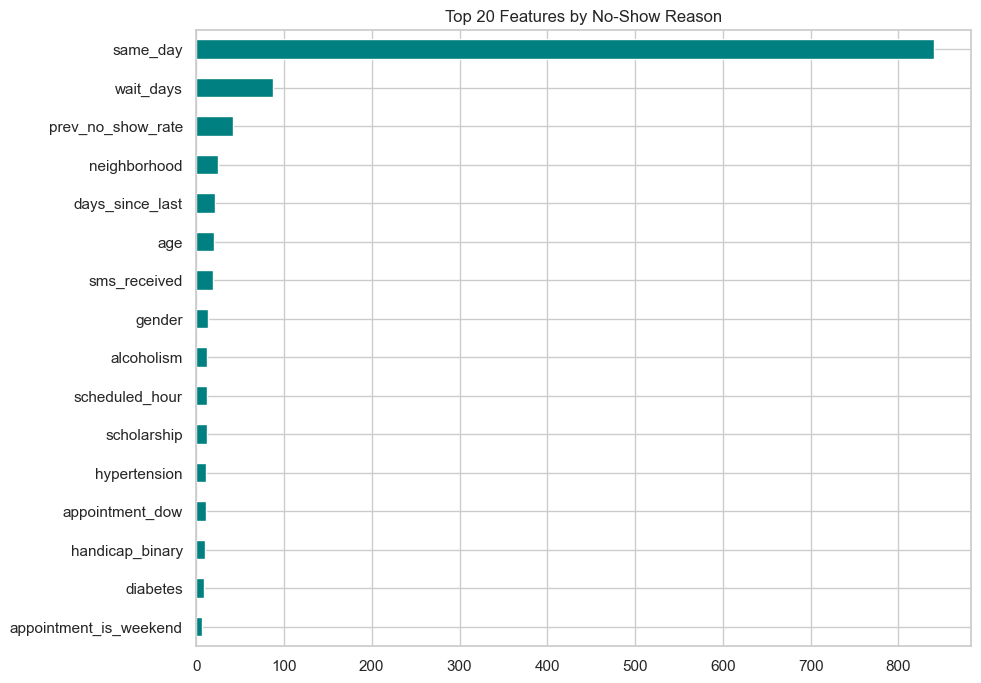

In [56]:
importances = pd.Series(
    bst.get_score(importance_type='gain'),
    index=X_train_tr.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh', color='teal')
plt.title('Top 20 Features by No-Show Reason')
plt.gca().invert_yaxis()
plt.show()

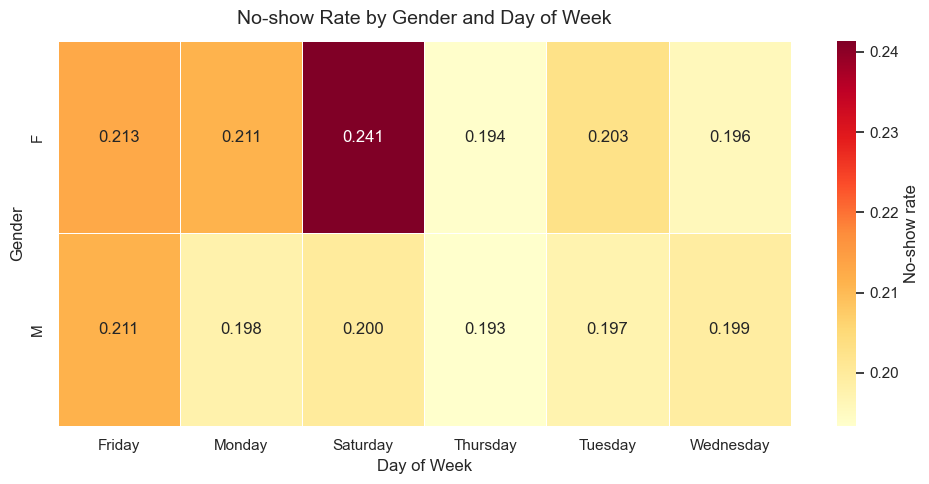

In [57]:
# No-show rate by Gender × Appointment Day of Week (heatmap style)
pivot_gender_dow = pd.pivot_table(
    df,
    values='target',
    index='gender',
    columns='appointment_dow',
    aggfunc='mean'
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_gender_dow,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'No-show rate'}
)
plt.title('No-show Rate by Gender and Day of Week', fontsize=14, pad=12)
plt.xlabel('Day of Week')
plt.ylabel('Gender')
plt.tight_layout()
plt.show()

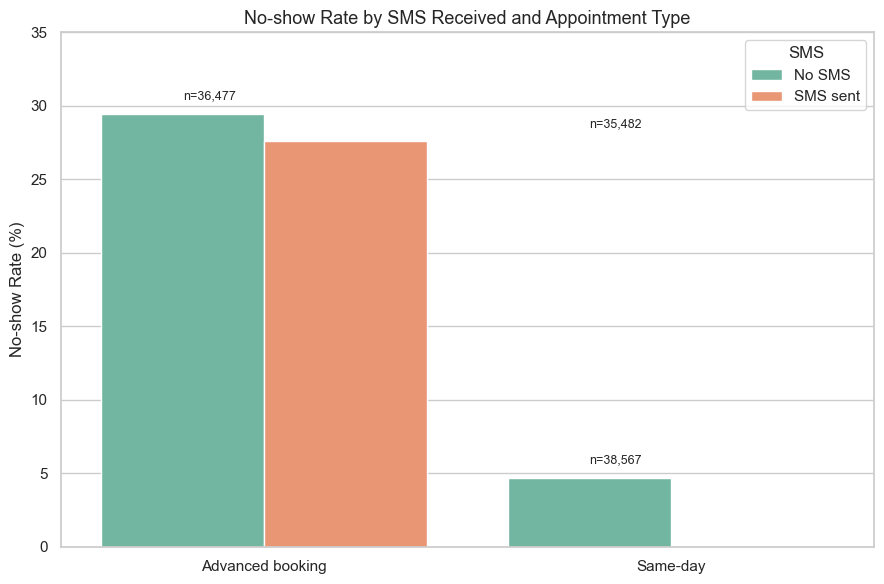

In [58]:
# No-show rate depending on SMS received and whether it's a same-day appointment
sms_same = df.groupby(['sms_received', 'same_day'])['target'].agg(['mean', 'count'])
sms_same['mean'] = sms_same['mean'] * 100  # to %

sms_same_reset = sms_same.reset_index()
sms_same_reset['sms_received'] = sms_same_reset['sms_received'].map({0: 'No SMS', 1: 'SMS sent'})
sms_same_reset['same_day'] = sms_same_reset['same_day'].map({0: 'Advanced booking', 1: 'Same-day'})

plt.figure(figsize=(9, 6))
sns.barplot(
    data=sms_same_reset,
    x='same_day',
    y='mean',
    hue='sms_received',
    palette='Set2'
)
plt.title('No-show Rate by SMS Received and Appointment Type', fontsize=13)
plt.ylabel('No-show Rate (%)')
plt.xlabel('')
plt.legend(title='SMS')
plt.ylim(0, 35)
for i, v in enumerate(sms_same_reset['count']):
    plt.text(i % 2 - 0.2 if i < 2 else i % 2 + 0.8,
             sms_same_reset['mean'].iloc[i] + 1,
             f'n={v:,}', fontsize=9)
plt.tight_layout()
plt.show()

/var/folders/vk/kp36p7g95xj99d7g2q4t3bmc0000gn/T/ipykernel_5358/4138146174.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=neigh_stats.index, y=neigh_stats['no_show_rate']*100,


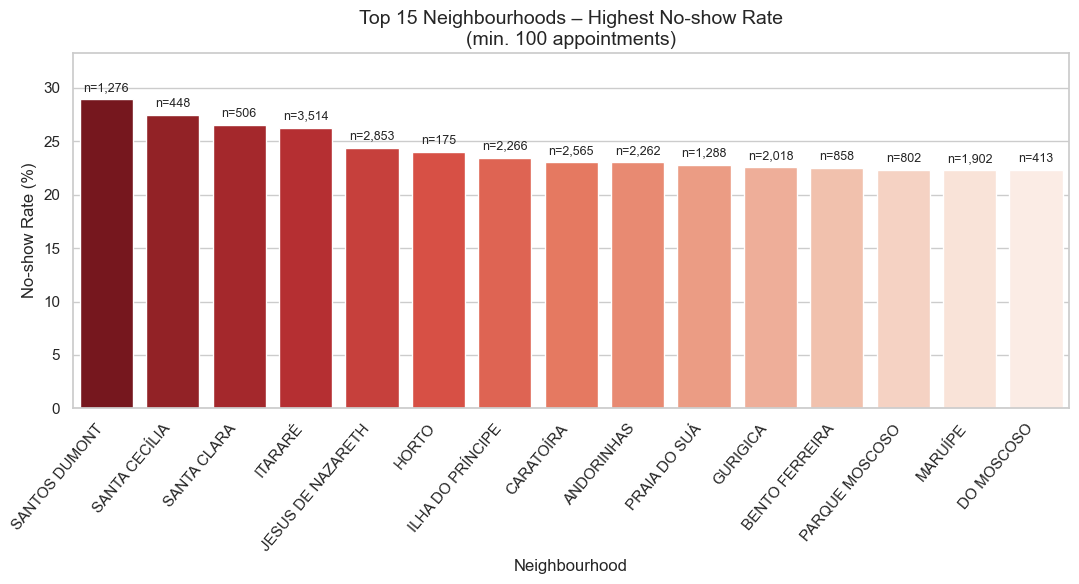

In [59]:
# Top 15 neighborhoods with highest no-show rate (only those with enough data)
neigh_stats = df.groupby('neighborhood').agg(
    no_show_rate=('target', 'mean'),
    count=('target', 'size')
).sort_values('no_show_rate', ascending=False)

# Filter to places with at least 100 appointments
neigh_stats = neigh_stats[neigh_stats['count'] >= 100].head(15)

plt.figure(figsize=(11, 6))
bars = sns.barplot(x=neigh_stats.index, y=neigh_stats['no_show_rate']*100,
                   palette='Reds_r')

plt.title('Top 15 Neighbourhoods – Highest No-show Rate\n(min. 100 appointments)', fontsize=14)
plt.ylabel('No-show Rate (%)')
plt.xlabel('Neighbourhood')
plt.xticks(rotation=50, ha='right')
plt.ylim(0, max(neigh_stats['no_show_rate']*100 * 1.15))

# Add count labels on bars
for bar, cnt in zip(bars.patches, neigh_stats['count']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'n={cnt:,}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

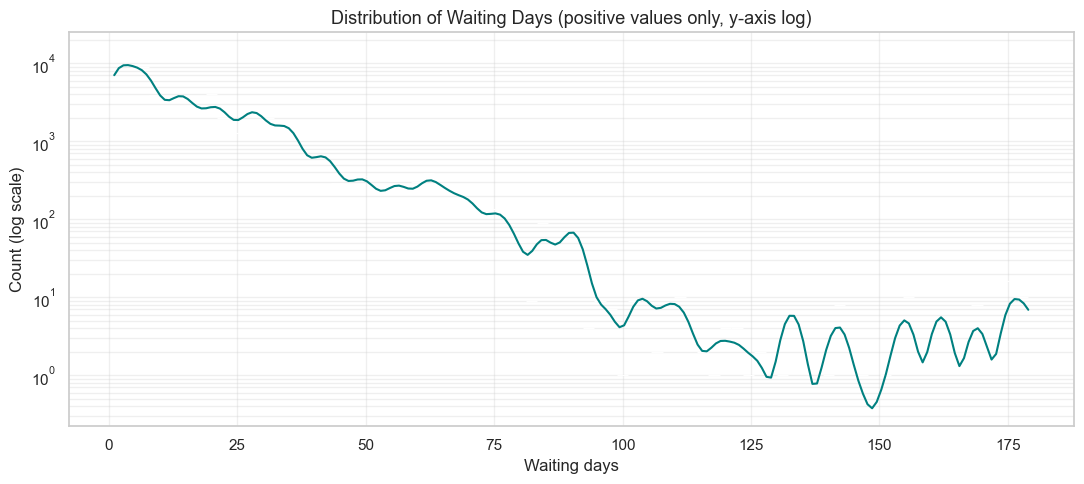

In [60]:
# Wait days distribution (log scale to see long tail)
plt.figure(figsize=(11, 5))

# Only positive wait days
wait_positive = df[df['wait_days'] > 0]['wait_days']

sns.histplot(wait_positive, bins=80, log_scale=(False, True), color='teal', kde=True)
plt.title('Distribution of Waiting Days (positive values only, y-axis log)', fontsize=13)
plt.xlabel('Waiting days')
plt.ylabel('Count (log scale)')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

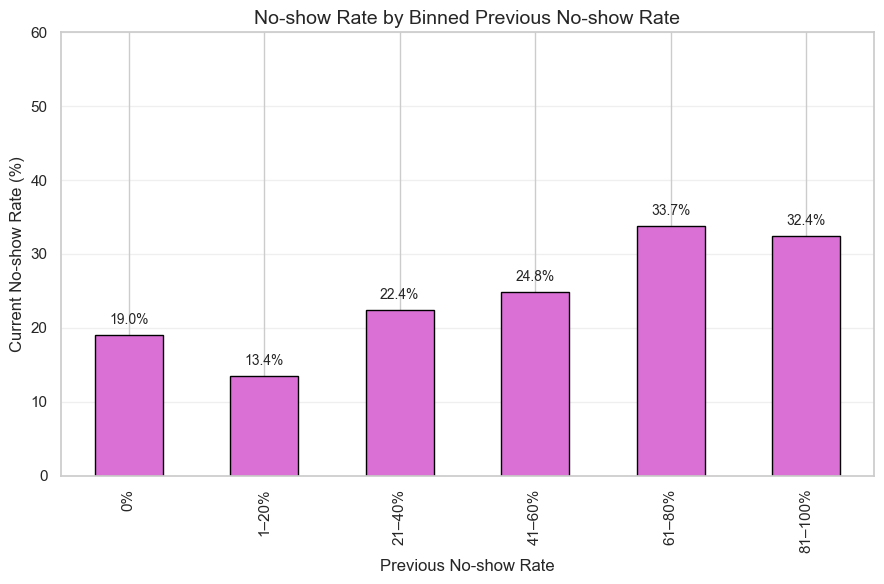

In [61]:
# Binned previous no-show rate vs current no-show probability
df['prev_rate_bin'] = pd.cut(
    df['prev_no_show_rate'],
    bins=[-0.01, 0, 0.2, 0.4, 0.6, 0.8, 1.01],
    labels=['0%', '1–20%', '21–40%', '41–60%', '61–80%', '81–100%']
)

prev_bin_rate = df.groupby('prev_rate_bin', observed=True)['target'].mean() * 100

plt.figure(figsize=(9, 6))
prev_bin_rate.plot(kind='bar', color='orchid', edgecolor='black')
plt.title('No-show Rate by Binned Previous No-show Rate', fontsize=14)
plt.ylabel('Current No-show Rate (%)')
plt.xlabel('Previous No-show Rate')
plt.ylim(0, 60)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(prev_bin_rate):
    plt.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()